# Plasma Dynamics Homework
**Author:** Isaac López

## Plasma Parameter Space Plot

In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({'figure.dpi':300})

/var/folders/8s/y523p2n90537hvsrfg9p12480000gn/T/ipykernel_75157/2403044009.py:100: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0, 0.78, 1])


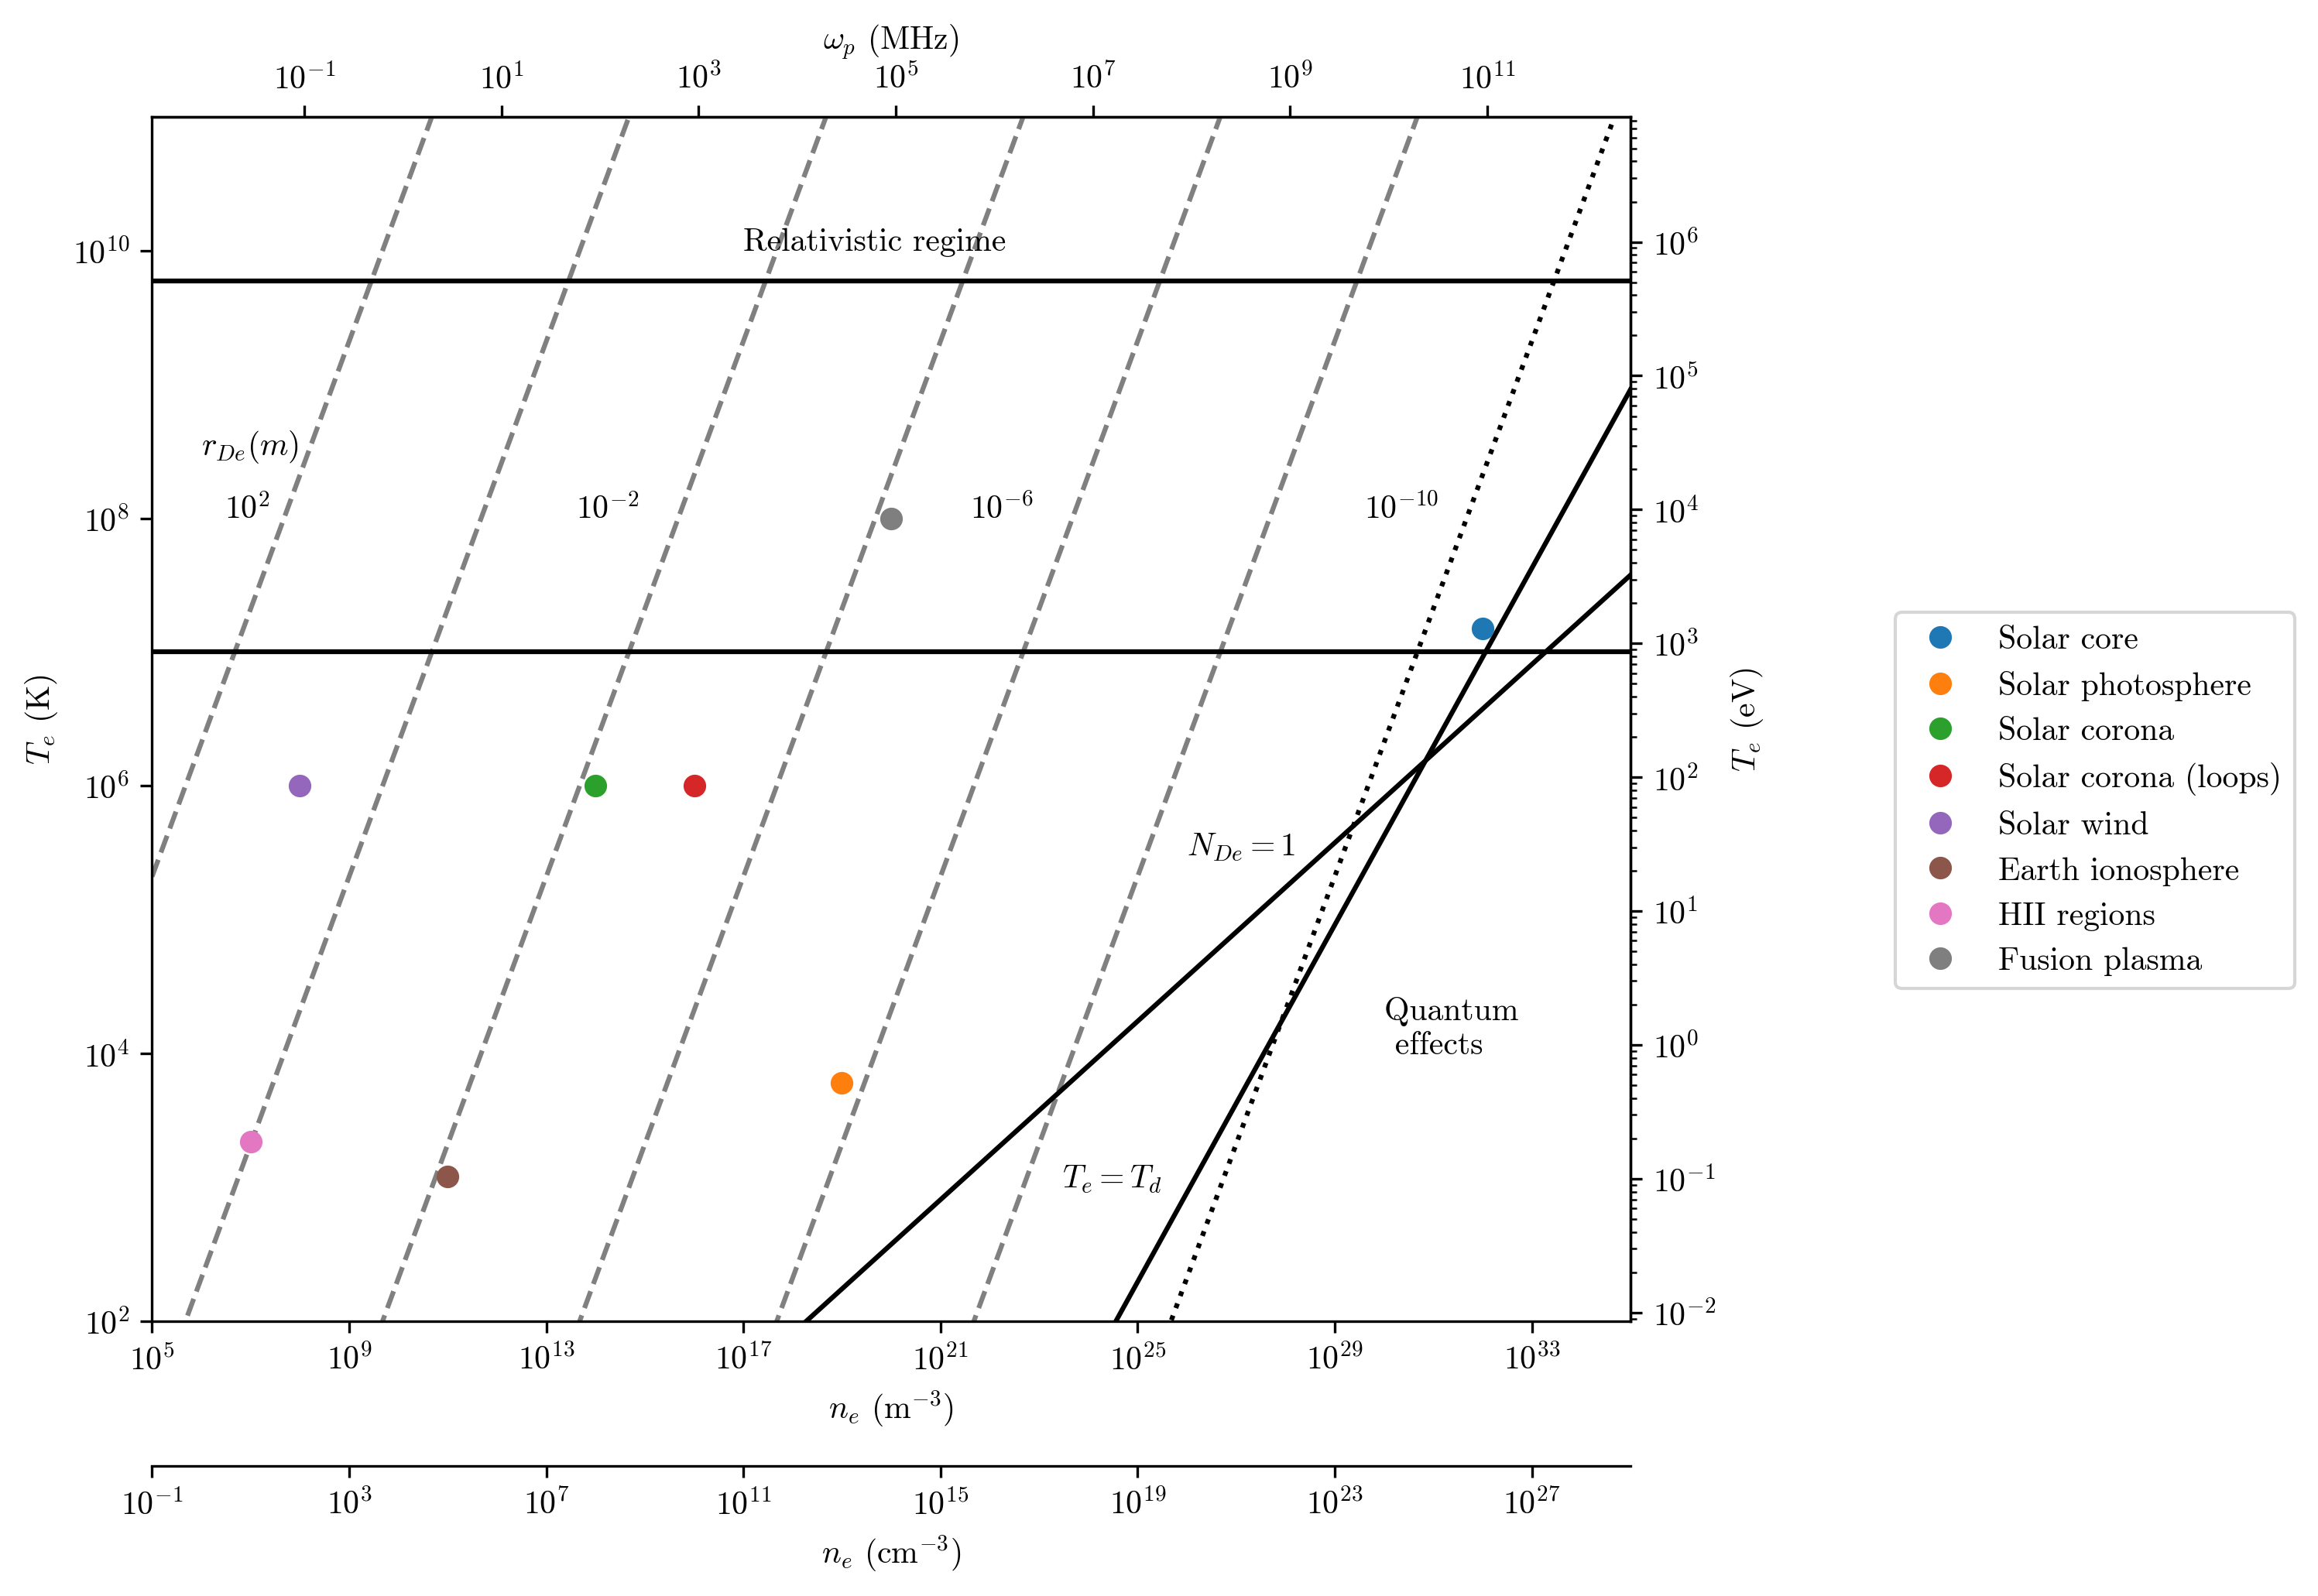

In [4]:
# Constants
eps0 = 8.854187817e-12  # Vacuum permittivity (F/m)
q = 1.602176634e-19      # Elementary charge (C)
k_B = 1.380649e-23       # Boltzmann constant (J/K)
m_e = 9.10938356e-31    # Electron mass (kg)
hbar = 1.0545718e-34   # Reduced Planck constant (J*s)
c = 299792458          # Speed of light (m/s)

# Function to calculate electron temperature from density and Debye radius
def T_e(n_e,r_d):
    return q**2/(eps0*k_B) * n_e * r_d**2

n_e = np.logspace(5,35,100) # Electron density range (m^-3)
r_d = [1e2,1e0,1e-2,1e-4,1e-6,1e-8,1e-10] # Debye radius (m)

# Functions to convert between plasma frequency and electron density
def get_f_pe(n_e):
    omega_pe = np.sqrt((n_e*q**2)/(eps0*m_e))
    return omega_pe/(2*np.pi) * 1e-6 # MHz

def get_n_e(f_pe):
    omega_pe = f_pe * 2 * np.pi * 1e6  # Convert MHz to rad/s
    return (omega_pe**2 * eps0 * m_e ) / q**2

# Create the plot
fig, ax = plt.subplots(figsize=(10, 7),constrained_layout=True)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$n_e$ (m$^{-3}$)')
ax.set_ylabel(r'$T_e$ (K)')
ax.set_ylim(1e2,1e11)
ax.set_xlim(1e5,1e35)

# Add secondary x-axis for plasma frequency
secax = ax.secondary_xaxis('top', functions=(get_f_pe, get_n_e))
secax.set_xlabel(r'$\omega_p$ (MHz)')

# Add secondary y-axis for electron temperature in eV
k_B_eV = k_B / q  # Boltzmann constant in eV/K
secax2 = ax.secondary_yaxis('right', functions=(lambda T:k_B_eV*T,lambda T:T/k_B_eV))
secax2.set_ylabel(r'$T_e$ (eV)')

# Constant Debye radius lines
for r in r_d:
    T = T_e(n_e,r)
    if r == 1e-10:
        ax.plot(n_e,T,color='k',linestyle=':')
    else:
        ax.plot(n_e,T,color='grey',linestyle='--')

ax.text(1e6,3e8,'$r_{De} (m)$')
ax.text(0.3e7,1e8,r'$10^2$')
ax.text(4e13,1e8,r'$10^{-2}$')
ax.text(4e21,1e8,r'$10^{-6}$')
ax.text(4e29,1e8,r'$10^{-10}$')

# N_De = 1
R_De = ((3/4)*(1/(np.pi*n_e)))**(1/3)
T_N_De = T_e(n_e,R_De)
ax.text(1e26,0.3e6,r'$N_{De}=1$')

ax.plot(n_e,T_N_De,color='k')

# Te = Td
E_f = (hbar**2/(2*m_e)) * (3*np.pi**2*n_e)**(2/3)  # Fermi energy
T_Td = E_f / k_B
ax.plot(n_e,T_Td,color='k')
ax.text(3e23,1e3,r'$T_e=T_d$')

# Relativistic regime
T_rel = m_e * c**2 / k_B 
plt.axhline(T_rel, color='k', linestyle='-')
ax.text(1e17,1e10,r'Relativistic regime')

# Plasma points
points = {'Solar core': (1e32,1.5e7),
          'Solar photosphere': (1e19,6000),
          'Solar corona': (1e14,1e6),
          'Solar corona (loops)': (1e16,1e6),
          'Solar wind': (10e7,10e5),
          'Earth ionosphere': (1e11,1.2e3),
          'HII regions': (9.94e6,2.18e3),
          'Fusion plasma': (1e20,1e8)}

for label, (n, T) in points.items():
    ax.plot(n, T, 'o', label=label)

# 10^7 K line
plt.axhline(y=1e7,color='k')

# Quantum effects region
ax.text(1e30,1e4,'Quantum \n effects')

# Secondary cm x axis
secax3 = ax.secondary_xaxis(location=-0.12, functions=(lambda n: n*1e-6, lambda f: f*1e6))
secax3.set_xlabel(r'$n_e$ (cm$^{-3}$)')

# Legend
fig.legend(fontsize='10',loc='right',bbox_to_anchor=(1, 0.5))
plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.savefig('plasma_plot.png')
plt.show()

## Solar Core Ionization Fraction

$$\frac{\alpha^2}{1-\alpha^2} = \frac{(2\pi m_e)^{3/2}}{h^3} \frac{(kT)^{5/2}}{P} \exp\left(-E_j/kT\right), \quad P = nkT, \quad E_j = 13.598\ \text{eV}$$

**For the SC:**

$$T \sim 1.57 \cdot 10^7\ \text{K}, \qquad n \sim 6 \cdot 10^{31}\ \text{m}^{-3}$$

$$\frac{\alpha^2}{1-\alpha^2} \approx 1.39$$

$$\alpha^2 = 1.39(1-\alpha^2)$$

$$\alpha^2 + 1.39\,\alpha^2 = 1.39$$

$$\alpha^2(1 + 1.39) = 1.39$$

$$\alpha = \sqrt{\frac{1.39}{1 + 1.39}} = 0.76$$

In [5]:
import numpy as np

# Constants
m_e = 9.10938356e-31  # Electron mass (kg)
h = 6.62607015e-34  # Planck's constant (J·s)
k_B = 1.380649e-23  # Boltzmann constant (J/K)

T_sc = 1.5e7  # Temperature of the solar core (K)
n_sc = 1e32 # Number density of particles in the solar core (particles/m^3)
E_j = 13.6  # Ionization energy of hydrogen (eV)

E_j = E_j * 1.60218e-19  # Convert eV to Joules

frac = (2*np.pi*m_e)**(3/2) / h**3 * (k_B * T_sc)**(5/2)/(n_sc * k_B * T_sc) * np.exp(-E_j / (k_B * T_sc))
alpha = np.sqrt(frac / (1 + frac))
print(f"Fraction of ionized hydrogen in the solar core: {alpha:.4f}")

Fraction of ionized hydrogen in the solar core: 0.7624
